
# 🐣 Human-Embryo *Phase Classifier* — End-to-End Notebook  

This notebook trains a deep network that maps a **single time-lapse frame**  
to its *morphokinetic phase* (`t2`, `t3`, …, `tB`).

## Paths

```python
PROJECT_ROOT            = Path("..")
ANNOT_DIR               = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'
```


In [12]:

# @title 🔧 Install & Imports

import random, re, math, json, os, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [ ]:

# @title 📁 Paths & Device
PROJECT_ROOT        = Path("..").resolve()
DATA_ROOT           = PROJECT_ROOT / 'data' / 'embryo_dataset_silver' / 'F0'
ANNOT_DIR           = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

assert DATA_ROOT.is_dir(), f"{DATA_ROOT} not found"
assert ANNOT_DIR.is_dir(), f"{ANNOT_DIR} not found"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)


Running on cuda


In [14]:
# @title 🚫 Embryo Exclusion List
EXCLUDE_EMBRYOS = {
    "BJ492-8",
    "ALR493-6"
}

In [15]:
# @title ⚙️ Helpers

PHASES = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]
PHASE2IDX = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE = {i: p for p, i in PHASE2IDX.items()}
NUM_CLASSES = len(PHASES)

def extract_frame_idx(name: str):
    m = re.search(r"(\d+)\.jpg$", name)
    return int(m.group(1)) if m else None

def index_frames(folder: Path):
    mapping = {}
    for fp in folder.glob("*.jpg"):
        m = re.search(r"(\d+)\.jpg$", fp.name)
        if m:
            mapping[int(m.group(1))] = fp
    return mapping

In [16]:
# @title 🗄️ PhaseDataset (filters empty frames)

FRAMES_PER_PHASE = 7      # None → keep all

class PhaseDataset(Dataset):
    def __init__(self, embryo_ids, transform,
                 frames_per_phase=10):
        self.transform = transform
        self.samples   = []           # [(img_path, label_idx), …]

        for eid in tqdm(embryo_ids):
            csv_path = ANNOT_DIR / f"{eid}_phases.csv"
            if not csv_path.is_file():      # skip missing
                print(f"Warning: missing annotation for {eid}, skipping")
                continue

            frame2path = index_frames(DATA_ROOT / eid)

            df = pd.read_csv(csv_path, header=None,
                             names=["phase", "start", "end"])

            for phase, start, end in df.itertuples(index=False):
                phase = str(phase).strip()
                if phase not in PHASE2IDX:          # unknown label → skip
                    continue

                # ---- subsample frames ----------------------------------
                if frames_per_phase and (end - start + 1) > frames_per_phase:
                    sel = np.linspace(start, end, frames_per_phase, dtype=int)
                else:
                    sel = range(start, end + 1)

                paths = [frame2path.get(f) for f in sel if frame2path.get(f)]

                lbl = PHASE2IDX[phase]
                for p in paths:
                    self.samples.append((p, lbl))

        print(f"Got {len(self.samples):,} frames")
        self.num_classes = NUM_CLASSES

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("L")
        return self.transform(img), torch.tensor(label)

In [17]:

# @title 🧰 Transforms & Data Split
MAX_EMBRYOS = None          # 25 for a quick run

IMG_SIZE = 256
# Common transforms for all sets (resize + normalize)
base_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),  # normalize all sets consistently
])

# Additional augmentations only for training
train_aug = v2.Compose([
    # Microscopy-specific augmentations
    v2.ColorJitter(
        brightness=0.6,  # wider brightness range
        contrast=0.6,    # wider contrast range
    ),
    # Enhance local features
    v2.RandomApply([
        v2.RandomAdjustSharpness(sharpness_factor=1.5)
    ], p=0.3),
    # Simulate focus variations
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3,3), sigma=(0.1, 1.0))
    ], p=0.3),
    # Mild geometric transformations (embryos don't rotate much in real life)
    v2.RandomAffine(
        degrees=180,             # Limited rotation
        translate=(0.05, 0.05), # Small translations
        scale=(0.85, 1.15),     # Minor scale changes
        shear=(-5, 5)           # Subtle shear
    ),
    # Custom augmentation for microscopy artifacts
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(5,5), sigma=(0.1, 0.5)),  # Simulate slight defocus
        v2.RandomAdjustSharpness(sharpness_factor=0.8)         # Simulate slight blur
    ], p=0.2),
])

# Training pipeline: base transforms -> augmentations -> normalize
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    train_aug,
    T.Normalize([0.5], [0.5])
])

# Val/Test pipeline: just the base transforms including normalization
val_tfm = base_tfm

In [18]:
# embryo-level split
all_embryos = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()
                      and p.name not in EXCLUDE_EMBRYOS])

random.seed(42)
random.shuffle(all_embryos)

# respect MAX_EMBRYOS
if MAX_EMBRYOS is not None:
    assert MAX_EMBRYOS >= 3, "Need ≥3 embryos to form train/val/test"
    all_embryos = all_embryos[:MAX_EMBRYOS]

n_val = max(1, int(0.10*len(all_embryos)))
n_test = max(1, int(0.10*len(all_embryos)))
val_embryos = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val+n_test]
train_embryos = all_embryos[n_val+n_test:]

print(f"Embryos ➜ train {len(train_embryos)} | val {len(val_embryos)} | test {len(test_embryos)}")

train_ds = PhaseDataset(train_embryos, transform=train_tfm, frames_per_phase=FRAMES_PER_PHASE)
val_ds   = PhaseDataset(val_embryos,   transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)
test_ds  = PhaseDataset(test_embryos,  transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)

from collections import Counter
train_labels = [lbl for _, lbl in train_ds.samples]
class_counts = Counter(train_labels)
num_classes  = train_ds.num_classes

# Weighted sampler for TRAIN to help rare phases
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler

sample_w = np.array([1.0 / class_counts[l] for _, l in train_ds.samples], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.from_numpy(sample_w), num_samples=len(sample_w), replacement=True)

BATCH = 32
train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=8, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)


Embryos ➜ train 562 | val 70 | test 70


100%|██████████| 562/562 [00:07<00:00, 78.29it/s] 


Got 41,376 frames


100%|██████████| 70/70 [00:00<00:00, 108.51it/s]


Got 5,227 frames


100%|██████████| 70/70 [00:00<00:00, 79.35it/s] 

Got 5,248 frames


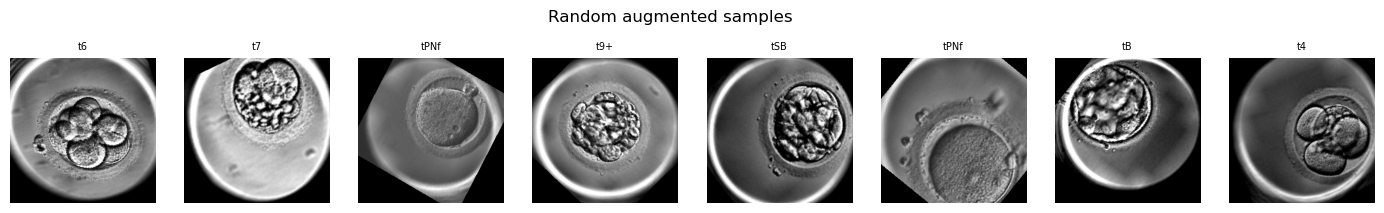

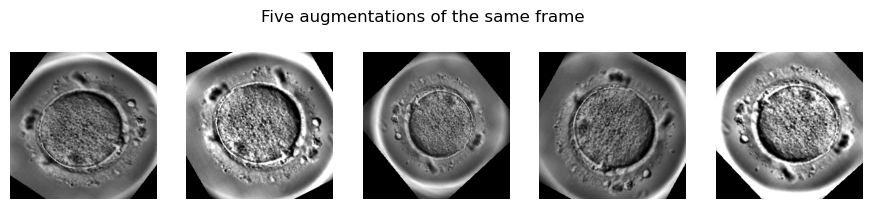

In [19]:
# @title 🔍 Preview data‐augmentations
import random, matplotlib.pyplot as plt
import torch

# -----------------------------------------------
# helper to de-normalise a 1×H×W tensor
def denorm(x):
    return (x*0.5 + 0.5).clamp(0,1).squeeze().cpu().numpy()

# 1)  Eight random augmented frames ----------------
N = 8
idxs = random.sample(range(len(train_ds)), N)
fig, axes = plt.subplots(1, N, figsize=(2.2*N, 2.5))

for ax, i in zip(axes, idxs):
    img, lbl = train_ds[i]
    ax.imshow(denorm(img), cmap='gray')
    ax.set_title(IDX2PHASE[lbl.item()], fontsize=7)
    ax.axis('off')
fig.suptitle("Random augmented samples", fontsize=12)
plt.show()

# 2)  Same frame, 5 different augmentations --------
idx = random.choice(range(len(train_ds)))
base_path, _ = train_ds.samples[idx]
base_img = Image.open(base_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
for ax in axes:
    aug = train_tfm(base_img)
    ax.imshow(denorm(aug), cmap='gray')
    ax.axis('off')
fig.suptitle("Five augmentations of the same frame", fontsize=12)
plt.show()


In [20]:

# @title 🧠 Model
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights


n_classes = train_ds.num_classes
model = efficientnet_v2_s(weights=None)

# Convert first layer to grayscale while preserving pre-trained weights
old_conv = model.features[0][0]
new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
# Average the RGB weights to create grayscale weights
with torch.no_grad():
    new_conv.weight.data = old_conv.weight.data.sum(dim=1, keepdim=True) / 3.0

model.features[0][0] = new_conv

# Enhanced classifier with batch norm and more capacity
in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_feats, n_classes)
)

model.to(device)

# Two-phase training setup
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-3, weight_decay=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=2, min_lr=1e-7, verbose=True
)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [21]:
MIXUP_ALPHA, MIXUP_PROB = 0.4, 0.6
def apply_mixup(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0 or x.size(0) < 2: return x, (y, None, 1.0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], (y, y[idx], lam)

In [22]:
EPOCHS = 100
PATIENCE = 10  # Early stopping patience

best_loss = float('inf')
best_state = None
epochs_no_improve = 0
loss_history = []

for epoch in range(1, EPOCHS+1):  
    # --- train ---
    model.train()
    tr_loss = 0.0
    tr_hits = 0
    for xb, yb in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        if np.random.rand() < MIXUP_PROB:
            xb, (y1, y2, lam) = apply_mixup(xb, yb)
            logits = model(xb)
            loss = lam*criterion(logits, y1) + (1-lam)*criterion(logits, y2)
        else:
            logits = model(xb)
            loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
        tr_hits += (logits.argmax(1) == yb).sum().item()
    tr_loss /= len(train_ds)
    tr_acc = tr_hits / len(train_ds)

    # --- val ---
    model.eval()
    val_loss = 0.0
    val_hits = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_hits += (logits.argmax(1) == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = val_hits / len(val_ds)

    # Step scheduler after each batch in train loop
    scheduler.step(val_loss)
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"[{epoch:02d}] train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | lr {curr_lr:.2e}")
    loss_history.append((tr_loss, val_loss))

    # --- early stop on val loss ---
    if val_loss < best_loss - 1e-6:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"\t*** New best! Val Loss: {val_loss:.4f} ***")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping after {epochs_no_improve} epochs.")
            break

# load best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

Epoch 1/100: 100%|██████████| 1293/1293 [02:34<00:00,  8.39it/s]


[01] train loss 2.7849 acc 0.062 | val loss 2.7805 acc 0.002 | lr 3.00e-03
	*** New best! Val Loss: 2.7805 ***


Epoch 2/100: 100%|██████████| 1293/1293 [02:40<00:00,  8.07it/s]


[02] train loss 2.7769 acc 0.062 | val loss 2.7741 acc 0.088 | lr 3.00e-03
	*** New best! Val Loss: 2.7741 ***


Epoch 3/100: 100%|██████████| 1293/1293 [02:36<00:00,  8.24it/s]


...

[77] train loss 1.5080 acc 0.485 | val loss 1.4231 acc 0.616 | lr 6.29e-04


Epoch 78/100: 100%|██████████| 1293/1293 [02:34<00:00,  8.36it/s]


[78] train loss 1.5217 acc 0.465 | val loss 1.4209 acc 0.626 | lr 5.03e-04


Epoch 79/100: 100%|██████████| 1293/1293 [02:32<00:00,  8.46it/s]


[79] train loss 1.5099 acc 0.473 | val loss 1.4189 acc 0.620 | lr 5.03e-04

Early stopping after 10 epochs.


Test inference: 100%|██████████| 164/164 [00:04<00:00, 40.76it/s]


              precision    recall  f1-score   support

        tPB2      0.699     0.890     0.783       420
        tPNa      0.858     0.736     0.792       469
        tPNf      0.669     0.794     0.726       466
          t2      0.828     0.806     0.817       485
          t3      0.450     0.643     0.529       154
          t4      0.756     0.643     0.695       468
          t5      0.357     0.466     0.404       264
          t6      0.373     0.300     0.333       290
          t7      0.339     0.305     0.321       279
          t8      0.602     0.572     0.587       423
         t9+      0.752     0.568     0.647       410
          tM      0.656     0.719     0.686       366
         tSB      0.662     0.628     0.645       331
          tB      0.539     0.650     0.589       223
         tEB      0.725     0.535     0.615       187
         tHB      1.000     0.385     0.556        13

    accuracy                          0.642      5248
   macro avg      0.642   

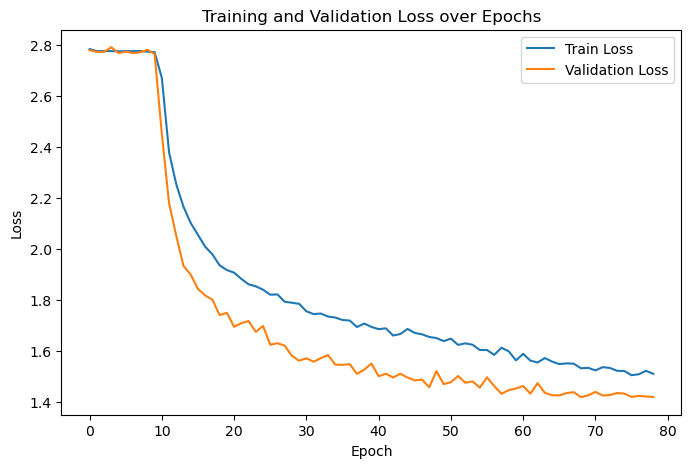

In [23]:
# @title 📊 Test‑Set Report
model.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in tqdm(test_dl, desc="Test inference"):
        logits = model(x.to(device))
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y.numpy())

# Get unique labels present in the test set
unique_labels = sorted(list(set(trues)))

# Filter and order target_names based on unique_labels
target_names = [IDX2PHASE[i] for i in sorted(set(trues))]


report = classification_report(trues, preds, labels=unique_labels, target_names=target_names, digits=3)
print(report)
cm = confusion_matrix(trues, preds, labels=unique_labels)
print("Confusion matrix\n", cm)

# loss history plot
train_losses, val_losses = zip(*loss_history)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [24]:

# @title 💾 Save Model
import datetime, torch
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"embryo_phase_models/phase_classifier_{timestamp}.pth"
torch.save(model, out_path)
print("Model saved to", out_path)


Model saved to embryo_phase_models/phase_classifier_20251022_165515.pth
